# Mixed-Type Recommender Systems: Implementation on MovieLens-1M

**Author:** Olusola Timothy Ogundepo  
**Supervisor:** Professor Ernest Fokoué  
**Institution:** African Institute for Mathematical Sciences (AIMS), Rwanda  
**Date:** April 2026

---

## Overview

This notebook contains the full implementation of the three recommender system models developed for my AIMS Rwanda research thesis. The central question is how different modelling families handle datasets that mix numerical, categorical, and binary features alongside user-item interaction data.

The three models are evaluated on the **MovieLens-1M** dataset under identical conditions, same data splits, same evaluation metrics, so that any difference in performance can be attributed to the modelling approach rather than experimental setup.

| Model | Approach | Mixed-Type Handling |
|---|---|---|
| Matrix Factorisation | Collaborative filtering baseline | None - ratings only |
| CatBoost | Tree-based gradient boosting | Native coordinate splits |
| LightGCN | Graph neural network | Input encoding + graph propagation |

**Evaluation metrics:** RMSE, MAE (prediction accuracy) and Precision@10, Recall@10, NDCG@10 (ranking quality).  
**Split strategy:** Time-based (train on oldest 80% of ratings, validate on next 10%, test on most recent 10%).

---
## Part 1: Setup

Imports and global configuration shared across all parts of the notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

In [2]:
np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 5)
plt.style.use('seaborn-v0_8-whitegrid')

In [3]:
DATA_DIR = Path().resolve() / 'datasets'

---
## Part 2: Data Loading and Exploration

MovieLens-1M consists of three files. Each uses `::` as a delimiter and has no header row.

- `ratings.dat`:  1,000,209 ratings from 6,040 users on ~3,900 movies
- `users.dat` (demographic attributes): gender (binary), age (ordinal bins), occupation (categorical)
- `movies.dat`:  movie title (with year) and pipe-separated genre flags (18 genres)

First, let's load them separately, inspect each, then merge into a single working DataFrame.

In [4]:
# Load ratings
ratings = pd.read_csv(
    DATA_DIR / 'ratings.dat',
    sep='::', header=None,
    names=['user_id', 'movie_id', 'rating', 'timestamp']
)

# Load users
users = pd.read_csv(
    DATA_DIR / 'users.dat',
    sep='::', header=None,
    names=['user_id', 'gender', 'age', 'occupation', 'zip_code']
)

# Load movies
movies = pd.read_csv(
    DATA_DIR / 'movies.dat',
    sep='::', header=None,
    names=['movie_id', 'title', 'genres'],
    encoding='latin-1'
)

In [5]:
print(f'Ratings:\t{ratings.shape}')
print(f'Users:\t\t{users.shape}')
print(f'Movies:\t\t{movies.shape}')

Ratings:	(1000209, 4)
Users:		(6040, 5)
Movies:		(3883, 3)


In [6]:

print('\nratings sample:')
print(ratings.head(4).to_string(index=False))

print('\nusers sample:')
print(users.head(4).to_string(index=False))

print('\nmovies sample:')
print(movies.head(4).to_string(index=False))


ratings sample:
 user_id  movie_id  rating  timestamp
       1      1193       5  978300760
       1       661       3  978302109
       1       914       3  978301968
       1      3408       4  978300275

users sample:
 user_id gender  age  occupation zip_code
       1      F    1          10    48067
       2      M   56          16    70072
       3      M   25          15    55117
       4      M   45           7    02460

movies sample:
 movie_id                    title                       genres
        1         Toy Story (1995)  Animation|Children's|Comedy
        2           Jumanji (1995) Adventure|Children's|Fantasy
        3  Grumpier Old Men (1995)               Comedy|Romance
        4 Waiting to Exhale (1995)                 Comedy|Drama


In [7]:
def date_extractor(df, minimum=True):
    if minimum:
        return pd.to_datetime(df["timestamp"].min(), unit="s").date()
    else:
        return pd.to_datetime(df["timestamp"].max(), unit="s").date()

In [8]:
# Basic statistics
n_users = ratings['user_id'].nunique()
n_movies = ratings['movie_id'].nunique()
n_zip_codes = users['zip_code'].nunique()
n_ratings = len(ratings)
sparsity = 1 - n_ratings / (n_users * n_movies)

print(f'Users:\t\t{n_users:,}')
print(f'Movies:\t\t{n_movies:,}')
print(f'Zip codes:\t{n_zip_codes:,}')
print(f'Ratings:\t{n_ratings:,}')
print(f'Period:\t\t{date_extractor(ratings, minimum=True)} - {date_extractor(ratings, minimum=False)}')
print(f'Sparsity:\t{sparsity:.2%}')
print(f'Rating range:\t{ratings["rating"].min()} - {ratings["rating"].max()}')
print(f'Mean rating:\t{ratings["rating"].mean():.3f}', end='\n\n')
print(f'Missing values:\n{ratings.isnull().sum().to_string()}', end='\n\n')
print(f'{users.isnull().sum().to_string()}', end='\n\n')
print(f'{movies.isnull().sum().to_string()}')

Users:		6,040
Movies:		3,706
Zip codes:	3,439
Ratings:	1,000,209
Period:		2000-04-25 - 2003-02-28
Sparsity:	95.53%
Rating range:	1 - 5
Mean rating:	3.582

Missing values:
user_id      0
movie_id     0
rating       0
timestamp    0

user_id       0
gender        0
age           0
occupation    0
zip_code      0

movie_id    0
title       0
genres      0


### MovieLens-1M Dataset Overview

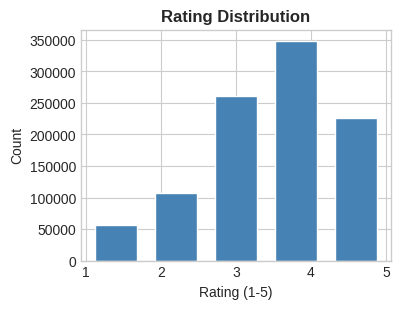

In [9]:
# Rating distribution
plt.figure(figsize=(4, 3))
plt.hist(ratings['rating'], bins=5, color='steelblue', edgecolor='white', rwidth=0.7)
plt.title('Rating Distribution', fontweight='bold')
plt.xlabel('Rating (1-5)')
plt.ylabel('Count');

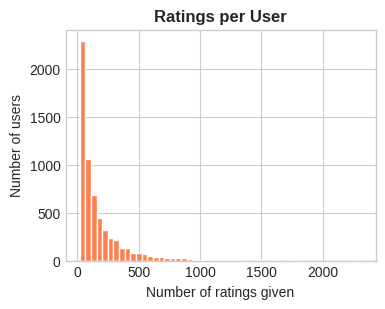

In [10]:
# Ratings per user
plt.figure(figsize=(4, 3))
ratings_per_user = ratings.groupby('user_id').size()
plt.hist(ratings_per_user, bins=50, color='coral', edgecolor='white')
plt.title('Ratings per User', fontweight='bold')
plt.xlabel('Number of ratings given')
plt.ylabel('Number of users');

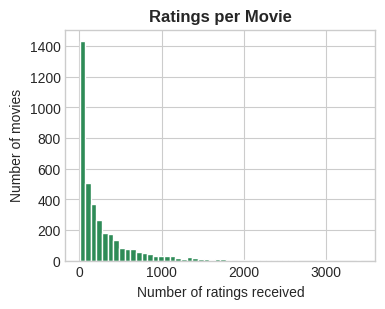

In [11]:
# Ratings per movie
plt.figure(figsize=(4, 3))
ratings_per_movie = ratings.groupby('movie_id').size()
plt.hist(ratings_per_movie, bins=50, color='seagreen', edgecolor='white')
plt.title('Ratings per Movie', fontweight='bold')
plt.xlabel('Number of ratings received')
plt.ylabel('Number of movies');

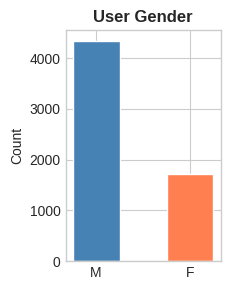

In [12]:
# Gender distribution
plt.figure(figsize=(2, 3))
gender_counts = users['gender'].value_counts()
plt.bar(gender_counts.index, gender_counts.values, color=['steelblue', 'coral'], width=0.5, edgecolor='white')
plt.title('User Gender', fontweight='bold')
plt.ylabel('Count');

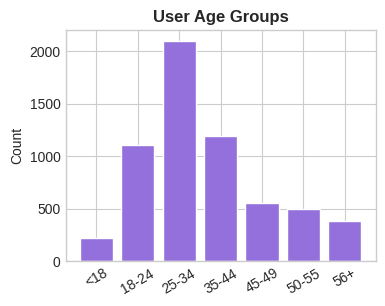

In [13]:
# Age distribution
age_labels = {1: '<18', 18: '18-24', 25: '25-34', 35: '35-44', 45: '45-49', 50: '50-55', 56: '56+'}
age_counts = users['age'].value_counts().sort_index()

plt.figure(figsize=(4, 3))
plt.bar([age_labels[a] for a in age_counts.index], age_counts.values, color='mediumpurple', edgecolor='white')
plt.title('User Age Groups', fontweight='bold')
plt.ylabel('Count')
plt.tick_params(axis='x', rotation=30);

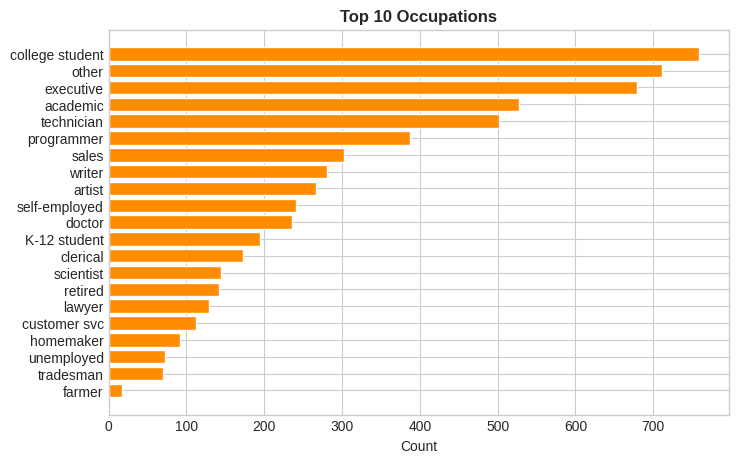

In [14]:
# Top 10 occupations
occ_map = {
    0: 'other', 1: 'academic', 2: 'artist', 3: 'clerical', 4: 'college student',
    5: 'customer svc', 6: 'doctor', 7: 'executive', 8: 'farmer', 9: 'homemaker',
    10: 'K-12 student', 11: 'lawyer', 12: 'programmer', 13: 'retired',
    14: 'sales', 15: 'scientist', 16: 'self-employed', 17: 'technician',
    18: 'tradesman', 19: 'unemployed', 20: 'writer'
}
occ_counts = users['occupation'].value_counts()
occ_counts.index = occ_counts.index.map(occ_map)

plt.figure(figsize=(8, 5))
plt.barh(occ_counts.index[::-1], occ_counts.values[::-1], color='darkorange', edgecolor='white')
plt.title('Top 10 Occupations', fontweight='bold')
plt.xlabel('Count');

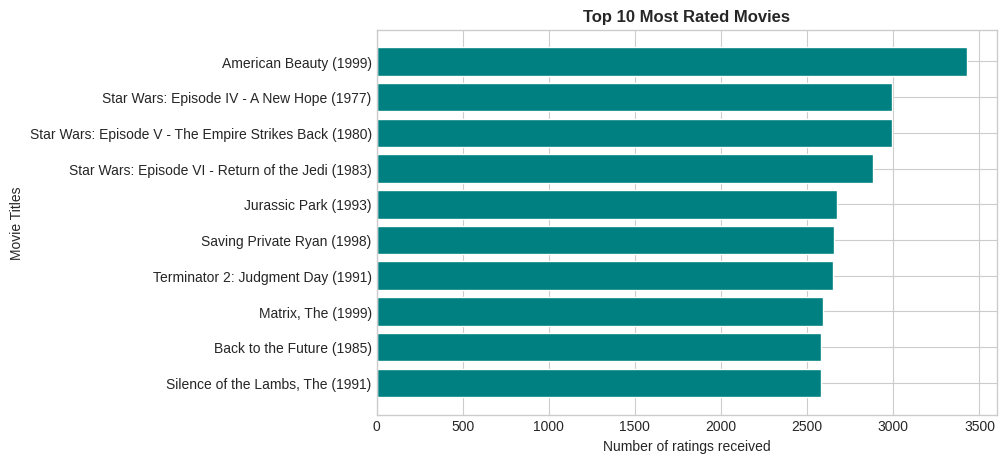

In [15]:
# Top 10 Most Rated Movies

top_movies = ratings['movie_id'].value_counts().head(10)
top_mid = top_movies.index
top_mtitles = movies.set_index('movie_id').loc[top_mid, 'title']
top_movie_counts = top_movies.values

plt.figure(figsize=(8, 5))
plt.barh(top_mtitles[::-1], top_movie_counts[::-1], color='teal', edgecolor='white')
plt.title('Top 10 Most Rated Movies', fontweight='bold')
plt.xlabel('Number of ratings received');
plt.ylabel('Movie Titles');

---
## Part 3: Feature Engineering

Before any model sees the data, I need to prepare the mixed-type features shared across all three pipelines. This is done once here so that every model is evaluated on an identical representation.

**User features:**
- `age` already a numerical value (1, 18, 25, 35, 45, 50, 56); and it can be treated as continuous and scaled using min-max $[0,1]$
- `gender` binary (M $\rightarrow 1$, F $\rightarrow 0$)
- `occupation` categorical (21 classes); kept as integer label for CatBoost (which handles it natively) and one-hot encoded where required

**Item features:**
- `year`: extracted from the title string (e.g. `Toy Story (1995)` $\rightarrow$ 1995); min-max help scale this to $[0,1]$
- 18 genre flags: each genre becomes a binary column (1 if the movie belongs to that genre, 0 otherwise)

**Split strategy:** time-based on the rating timestamp, oldest 80% for training, next 10% for validation, most recent 10% for testing. This reflects the real deployment scenario, a model always predicts future preferences from past behaviour.

In [16]:
# User features
users_feat = users[['user_id', 'gender', 'age', 'occupation']].copy()
users_feat['gender'] = (users_feat['gender'] == 'M').astype(int)

scaler_age = MinMaxScaler()
users_feat['age_scaled'] = scaler_age.fit_transform(users_feat[['age']])

print('user features:')
print(users_feat.head(4).to_string(index=False))

user features:
 user_id  gender  age  occupation  age_scaled
       1       0    1          10    0.000000
       2       1   56          16    1.000000
       3       1   25          15    0.436364
       4       1   45           7    0.800000


In [17]:
# Item features
ALL_GENRES = [
    'Action', 'Adventure', 'Animation', "Children's", 'Comedy', 'Crime',
    'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical',
    'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western'
]

movies_feat = movies[['movie_id', 'title', 'genres']].copy()
movies_feat['year'] = movies_feat['title'].str.extract(r'\((\d{4})\)').astype(float)

for genre in ALL_GENRES:
    movies_feat[genre] = movies_feat['genres'].str.contains(genre, regex=False).astype(int)

scaler_year = MinMaxScaler()
movies_feat['year_scaled'] = scaler_year.fit_transform(movies_feat[['year']])

print(f'item features shape: {movies_feat.shape}')
print(f'year range: {int(movies_feat["year"].min())} - {int(movies_feat["year"].max())}')
print(f'missing years: {movies_feat["year"].isna().sum()}')
print('\nsample (first 4 rows, selected columns):')
print(movies_feat[['movie_id', 'title', 'year_scaled'] + ALL_GENRES[:4]].head(4).to_string(index=False))

item features shape: (3883, 23)
year range: 1919 - 2000
missing years: 0

sample (first 4 rows, selected columns):
 movie_id                    title  year_scaled  Action  Adventure  Animation  Children's
        1         Toy Story (1995)     0.938272       0          0          1           1
        2           Jumanji (1995)     0.938272       0          1          0           1
        3  Grumpier Old Men (1995)     0.938272       0          0          0           0
        4 Waiting to Exhale (1995)     0.938272       0          0          0           0


In [18]:
# Time-based train / val / test split
ratings_sorted = ratings.sort_values('timestamp').reset_index(drop=True)

n = len(ratings_sorted)
train_end = int(n * 0.80)
val_end = int(n * 0.90)

train_raw = ratings_sorted.iloc[:train_end].copy()
val_raw = ratings_sorted.iloc[train_end:val_end].copy()
test_raw = ratings_sorted.iloc[val_end:].copy()

In [19]:
print(f'Train:\t{len(train_raw):,}\tratings ({len(train_raw)/n:.0%})')
print(f'Val:\t{len(val_raw):,}\tratings ({len(val_raw)/n:.0%})')
print(f'Test:\t{len(test_raw):,}\tratings ({len(test_raw)/n:.0%})')

print(f'\nTrain timestamp range: \t{date_extractor(train_raw, True)}'
      f' to {date_extractor(train_raw, False)}')
print(f'Val timestamp range: \t{date_extractor(val_raw, True)} to '
      f'{date_extractor(val_raw, False)}')
print(f'Test timestamp range: \t{date_extractor(test_raw, True)} to '
      f'{date_extractor(test_raw, False)}')

Train:	800,167	ratings (80%)
Val:	100,021	ratings (10%)
Test:	100,021	ratings (10%)

Train timestamp range: 	2000-04-25 to 2000-12-02
Val timestamp range: 	2000-12-02 to 2000-12-29
Test timestamp range: 	2000-12-29 to 2003-02-28


---
## Part 4: Matrix Factorisation (Baseline)

Matrix factorisation is the standard collaborative filtering baseline. It uses **only the rating matrix**: no user or item attributes at all. Any gain from CatBoost or LightGCN above this baseline is attributable to the mixed-type features they additionally exploit.

The rating matrix $R \in \mathbb{R}^{m \times n}$ is approximated as a product of two low-rank matrices:

$$R \approx PQ^\top, \quad P \in \mathbb{R}^{m \times k},\ Q \in \mathbb{R}^{n \times k}$$

where $\mathbf{p}_u \in \mathbb{R}^k$ is a latent user embedding and $\mathbf{q}_i \in \mathbb{R}^k$ is a latent item embedding. The predicted rating, including user bias $b_u$, item bias $b_i$, and global mean $\mu$, is:

$$\hat{r}_{ui} = \mu + b_u + b_i + \mathbf{p}_u \cdot \mathbf{q}_i$$

Training minimises the regularised squared error over observed ratings:

$$\mathcal{L} = \sum_{(u,i) \in \mathcal{K}} \left(r_{ui} - \hat{r}_{ui}\right)^2 + \lambda\left(\|\mathbf{p}_u\|^2 + \|\mathbf{q}_i\|^2 + b_u^2 + b_i^2\right)$$

Parameters are updated by stochastic gradient descent (SGD). At each step, the error is $e_{ui} = r_{ui} - \hat{r}_{ui}$ and the updates are:

$$\mathbf{p}_u \leftarrow \mathbf{p}_u + \alpha\left(e_{ui}\,\mathbf{q}_i - \lambda\,\mathbf{p}_u\right)$$
$$\mathbf{q}_i \leftarrow \mathbf{q}_i + \alpha\left(e_{ui}\,\mathbf{p}_u - \lambda\,\mathbf{q}_i\right)$$
$$b_u \leftarrow b_u + \alpha\left(e_{ui} - \lambda\, b_u\right), \quad b_i \leftarrow b_i + \alpha\left(e_{ui} - \lambda\, b_i\right)$$

where $\alpha$ is the learning rate and $\lambda$ is the regularisation coefficient.

In [20]:
all_user_ids = sorted(ratings['user_id'].unique())
all_movie_ids = sorted(ratings['movie_id'].unique())

user_to_idx = {u: i for i, u in enumerate(all_user_ids)}
movie_to_idx = {m: i for i, m in enumerate(all_movie_ids)}

n_u = len(all_user_ids)
n_m = len(all_movie_ids)

print(f'Users in index:\t\t{n_u:,}')
print(f'Movies in index:\t{n_m:,}')

Users in index:		6,040
Movies in index:	3,706


In [21]:
class MatrixFactorisation:
    """
    SGD-based matrix factorisation with user/item biases.
    Prediction: r_hat = mu + b_u + b_i + p_u . q_i
    """
    def __init__(self, n_users, n_items, k=20, lr=0.005, reg=0.02, n_epochs=20):
        self.k = k
        self.lr = lr
        self.reg = reg
        self.n_epochs = n_epochs
        self.P = np.random.normal(0, 0.1, (n_users, k))
        self.Q = np.random.normal(0, 0.1, (n_items, k))
        self.b_u = np.zeros(n_users)
        self.b_i = np.zeros(n_items)
        self.mu = 0.0

    def fit(self, train_df, val_df=None):
        self.mu = train_df['rating'].mean()
        u_idx = train_df['user_id'].map(user_to_idx).values
        i_idx = train_df['movie_id'].map(movie_to_idx).values
        r = train_df['rating'].values.astype(float)

        for epoch in range(self.n_epochs):
            order = np.random.permutation(len(r))
            for idx in order:
                u, i, rui = u_idx[idx], i_idx[idx], r[idx]
                e = rui - (self.mu + self.b_u[u] + self.b_i[i] + self.P[u] @ self.Q[i])
                self.P[u] += self.lr * (e * self.Q[i] - self.reg * self.P[u])
                self.Q[i] += self.lr * (e * self.P[u] - self.reg * self.Q[i])
                self.b_u[u] += self.lr * (e - self.reg * self.b_u[u])
                self.b_i[i] += self.lr * (e - self.reg * self.b_i[i])

            if val_df is not None and (epoch + 1) % 5 == 0:
                val_rmse = self._rmse(val_df)
                print(f'  epoch {epoch+1:>2}/{self.n_epochs}  val RMSE: {val_rmse:.4f}')

    def predict(self, user_id, movie_id):
        u = user_to_idx.get(user_id)
        i = movie_to_idx.get(movie_id)
        if u is None or i is None:
            return self.mu
        return float(np.clip(self.mu + self.b_u[u] + self.b_i[i] + self.P[u] @ self.Q[i], 1.0, 5.0))

    def _rmse(self, df):
        preds = [self.predict(r.user_id, r.movie_id) for r in df.itertuples()]
        return float(np.sqrt(mean_squared_error(df['rating'].values, preds)))

In [22]:
mf = MatrixFactorisation(n_u, n_m, k=20, lr=0.005, reg=0.02, n_epochs=20)
print('Training MF (SGD, 20 epochs)...')
mf.fit(train_raw, val_df=val_raw)

Training MF (SGD, 20 epochs)...
  epoch  5/20  val RMSE: 0.9732
  epoch 10/20  val RMSE: 0.9686
  epoch 15/20  val RMSE: 0.9654
  epoch 20/20  val RMSE: 0.9648


In [23]:
test_preds = [mf.predict(r.user_id, r.movie_id) for r in test_raw.itertuples()]
test_actuals = test_raw['rating'].values.astype(float)

mf_rmse = float(np.sqrt(mean_squared_error(test_actuals, test_preds)))
mf_mae  = float(mean_absolute_error(test_actuals, test_preds))

print(f'MF  RMSE:\t{mf_rmse:.4f}')
print(f'MF  MAE:\t{mf_mae:.4f}')

MF  RMSE:	0.9155
MF  MAE:	0.7170


In [24]:
def ranking_metrics(model_predict, test_df, train_df, K=10, threshold=4.0, n_users=200):
    """
    Compute Precision@K, Recall@K and NDCG@K for a given predict function.
    Evaluates on a random sample of test users who have at least 1 relevant item.
    """
    train_seen = train_df.groupby('user_id')['movie_id'].apply(set).to_dict()
    test_relevant = (
        test_df[test_df['rating'] >= threshold]
        .groupby('user_id')['movie_id'].apply(set).to_dict()
    )

    rng = np.random.default_rng(42)
    candidates = [u for u in test_relevant if len(test_relevant[u]) > 0]
    sampled = rng.choice(candidates, size=min(n_users, len(candidates)), replace=False)

    p_scores, r_scores, ndcg_scores = [], [], []

    for uid in sampled:
        seen = train_seen.get(uid, set())
        relevant = test_relevant[uid]
        unrated = [m for m in all_movie_ids if m not in seen]

        scores = np.array([model_predict(uid, m) for m in unrated])
        top_k = [unrated[j] for j in np.argsort(scores)[::-1][:K]]

        hits = [1.0 if m in relevant else 0.0 for m in top_k]
        precision = sum(hits) / K
        recall = sum(hits) / len(relevant) if relevant else 0.0

        dcg = sum(h / np.log2(r + 2) for r, h in enumerate(hits))
        ideal = sum(1.0 / np.log2(r + 2) for r in range(min(K, len(relevant))))
        ndcg = dcg / ideal if ideal > 0 else 0.0

        p_scores.append(precision)
        r_scores.append(recall)
        ndcg_scores.append(ndcg)

    return np.mean(p_scores), np.mean(r_scores), np.mean(ndcg_scores)


mf_p10, mf_r10, mf_ndcg10 = ranking_metrics(mf.predict, test_raw, train_raw, K=10)
print(f'MF  Precision@10:\t{mf_p10:.4f}')
print(f'MF  Recall@10:\t\t{mf_r10:.4f}')
print(f'MF  NDCG@10:\t\t{mf_ndcg10:.4f}')

MF  Precision@10:	0.1230
MF  Recall@10:		0.0345
MF  NDCG@10:		0.1283


In [25]:
def recommend_top_k(model_predict, user_id, train_df, k=10):
    seen = set(train_df[train_df['user_id'] == user_id]['movie_id'])
    unrated = [m for m in all_movie_ids if m not in seen]
    scores = np.array([model_predict(user_id, m) for m in unrated])
    top_idx = np.argsort(scores)[::-1][:k]
    top_ids = [unrated[j] for j in top_idx]
    top_scores = scores[top_idx]
    result = movies_feat[movies_feat['movie_id'].isin(top_ids)][['movie_id', 'title']].copy()
    score_map = dict(zip(top_ids, top_scores))
    result['pred_score'] = result['movie_id'].map(score_map).round(3)
    return result.sort_values('pred_score', ascending=False).reset_index(drop=True)


sample_user = 1
print(f'Top-10 recommendations for user {sample_user} (MF):')
print(recommend_top_k(mf.predict, sample_user, train_raw).to_string(index=False))

Top-10 recommendations for user 1 (MF):
 movie_id                            title  pred_score
     2905                   Sanjuro (1962)       4.695
      318 Shawshank Redemption, The (1994)       4.486
     3949       Requiem for a Dream (2000)       4.470
     1262         Great Escape, The (1963)       4.470
     1240           Terminator, The (1984)       4.446
      858            Godfather, The (1972)       4.443
     1198   Raiders of the Lost Ark (1981)       4.442
       50       Usual Suspects, The (1995)       4.441
     3306               Circus, The (1928)       4.439
     3038      Face in the Crowd, A (1957)       4.435


---
### Part 4b: BPR Matrix Factorisation (Pairwise Ranking Baseline)

The matrix factorisation model in Part 4 is trained to minimise squared error on observed ratings, which is a *pointwise* objective. A pointwise objective is well aligned with RMSE and MAE but is not aligned with the top-$K$ ranking task: nothing in the loss rewards placing relevant items above irrelevant ones for the same user. Bayesian Personalised Ranking (BPR) replaces that loss with a *pairwise* objective that does exactly that:

$$\mathcal{L}_{\mathrm{BPR}} = -\sum_{(u,\, i^{+},\, i^{-})} \ln \sigma\!\bigl(\mathbf{p}_u \cdot \mathbf{q}_{i^{+}} - \mathbf{p}_u \cdot \mathbf{q}_{i^{-}}\bigr) + \lambda\bigl(\|\mathbf{p}_u\|^2 + \|\mathbf{q}_{i^{+}}\|^2 + \|\mathbf{q}_{i^{-}}\|^2\bigr)$$

where $i^{+}$ is an item the user rated highly ($r_{ui^{+}} \geq 4$) in the training set and $i^{-}$ is sampled uniformly from items the user has not rated. The score used for top-$K$ ranking is the inner product $\mathbf{p}_u \cdot \mathbf{q}_i$ (no biases; biases cancel in the pairwise difference).

The latent dimension ($k=20$), learning rate ($0.005$), L2 regularisation ($0.02$), and number of epochs ($20$) are matched to the pointwise MF of Part 4, so any difference in ranking performance is attributable to the change of objective alone. RMSE and MAE are not meaningful for BPR-MF and are reported as $-$ in the comparison table.



In [26]:
import torch
import torch.nn.functional as F

torch.manual_seed(42)


class BPRMF(torch.nn.Module):
    """Bayesian Personalised Ranking MF (no biases, they cancel in the pairwise diff)."""
    def __init__(self, n_users, n_items, k=20):
        super().__init__()
        self.user_emb = torch.nn.Embedding(n_users, k)
        self.item_emb = torch.nn.Embedding(n_items, k)
        torch.nn.init.normal_(self.user_emb.weight, std=0.1)
        torch.nn.init.normal_(self.item_emb.weight, std=0.1)

    def score_diff(self, u, i_pos, i_neg):
        return (self.user_emb(u) * (self.item_emb(i_pos) - self.item_emb(i_neg))).sum(-1)


# Positives: training ratings with r >= 4
pos_df = train_raw[train_raw['rating'] >= 4.0]
pos_u = torch.tensor(pos_df['user_id'].map(user_to_idx).values, dtype=torch.long)
pos_i = torch.tensor(pos_df['movie_id'].map(movie_to_idx).values, dtype=torch.long)
N_POS = pos_u.shape[0]

print(f'BPR training positives (r >= 4):\t{N_POS:,}  '
      f'({100 * N_POS / len(train_raw):.1f}% of train ratings)')

# k, lr, epochs match pointwise MF so only the objective differs.
# Matching reg=0.02 collapses BPR embeddings to noise (no rating-scale anchor),
# so we use a mild Adam weight_decay instead.
bpr = BPRMF(n_u, n_m, k=20)
optimizer = torch.optim.Adam(bpr.parameters(), lr=5e-3, weight_decay=1e-6)

N_EPOCHS = 20
BATCH = 8192

print('Training BPR-MF (pairwise, mini-batch Adam)...')
print(f'{"Epoch":>6} {"BPR loss":>10}')

for epoch in range(1, N_EPOCHS + 1):
    bpr.train()
    perm = torch.randperm(N_POS)
    total_loss, total_n = 0.0, 0
    for s in range(0, N_POS, BATCH):
        idx = perm[s:s + BATCH]
        bu = pos_u[idx]
        bi = pos_i[idx]
        # uniform negative sampling, no rejection (rated share per user is tiny)
        bj = torch.randint(0, n_m, (len(idx),), dtype=torch.long)

        optimizer.zero_grad()
        diff = bpr.score_diff(bu, bi, bj)
        loss = -F.logsigmoid(diff).mean()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(idx)
        total_n += len(idx)

    if epoch == 1 or epoch % 5 == 0:
        print(f'{epoch:>6} {total_loss / total_n:>10.4f}')

# numpy copies for fast batched scoring during ranking eval
_bpr_P = bpr.user_emb.weight.detach().numpy()
_bpr_Q = bpr.item_emb.weight.detach().numpy()
print('BPR-MF training complete.')


BPR training positives (r >= 4):	463,020  (57.9% of train ratings)
Training BPR-MF (pairwise, mini-batch Adam)...
 Epoch   BPR loss
     1     0.6911
     5     0.2874
    10     0.2221
    15     0.1964
    20     0.1842
BPR-MF training complete.


---
## Part 5: CatBoost (Gradient Boosting with Native Categorical Handling)

CatBoost converts rating prediction into a supervised regression problem. Each training example is a (user, movie) pair represented as a fixed-length feature vector, and the model fits an ensemble of $T$ gradient-boosted oblivious trees:

$$\hat{r}_{ui} = F_T(z_u, x_i) = F_0 + \sum_{t=1}^{T} \gamma_t\, h_t(z_u, x_i)$$

where $F_0$ is the global ratings mean, and  $\gamma_t$ is the weight of tree $t$ and $T$ is determined by early stopping on validation RMSE. Two feature configurations are evaluated:

- **Part 5a (base, 22 features):** raw demographic and item side features only, no interaction history.
- **Part 5b (extended, 42 features):** adds user genre affinities and item statistics derived from training ratings.


### Part 5a: CatBoost Base (22 Features)

A minimal configuration using only the raw side features: $z_u = (g_u,\ a_u,\ o_u)$ and $x_i = (y_i,\ x_{i,1},\ldots,x_{i,18})$, giving 22 features in total. No statistics are pre-computed from training ratings.


In [27]:
from catboost import CatBoostRegressor, Pool

# Base feature columns: 3 user demo + 1 year + 18 genres = 22 features, no interaction history
FEATURE_COLS_BASE = (
    ['gender', 'age_scaled', 'occupation']
    + ['year_scaled']
    + ALL_GENRES
)
CAT_COLS_BASE = ['occupation']

def build_cb_base_df(ratings_df):
    df = ratings_df.merge(
        users_feat[['user_id', 'gender', 'age_scaled', 'occupation']], on='user_id'
    )
    df = df.merge(
        movies_feat[['movie_id', 'year_scaled'] + ALL_GENRES], on='movie_id'
    )
    return df

train_cb_base = build_cb_base_df(train_raw)
val_cb_base = build_cb_base_df(val_raw)
test_cb_base = build_cb_base_df(test_raw)

print(f'Features (base):\t{len(FEATURE_COLS_BASE)}  ({len(CAT_COLS_BASE)} categorical: {CAT_COLS_BASE})')

train_pool_base = Pool(train_cb_base[FEATURE_COLS_BASE], train_cb_base['rating'], cat_features=CAT_COLS_BASE)
val_pool_base = Pool(val_cb_base[FEATURE_COLS_BASE],   val_cb_base['rating'],   cat_features=CAT_COLS_BASE)

cb_base_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    early_stopping_rounds=20,
    verbose=50
)

print('Training CatBoost (base)...')
cb_base_model.fit(train_pool_base, eval_set=val_pool_base)


Features (base):	22  (1 categorical: ['occupation'])
Training CatBoost (base)...
0:	learn: 1.1171556	test: 1.1161504	best: 1.1161504 (0)	total: 161ms	remaining: 1m 20s
50:	learn: 1.0742256	test: 1.0773157	best: 1.0773157 (50)	total: 3.87s	remaining: 34.1s
100:	learn: 1.0652097	test: 1.0702862	best: 1.0702862 (100)	total: 7.73s	remaining: 30.5s
150:	learn: 1.0589796	test: 1.0652455	best: 1.0652455 (150)	total: 11.4s	remaining: 26.3s
200:	learn: 1.0544962	test: 1.0617886	best: 1.0617886 (200)	total: 15s	remaining: 22.3s
250:	learn: 1.0510505	test: 1.0594810	best: 1.0594810 (250)	total: 18.7s	remaining: 18.5s
300:	learn: 1.0481097	test: 1.0571883	best: 1.0571883 (300)	total: 22.3s	remaining: 14.8s
350:	learn: 1.0457884	test: 1.0550817	best: 1.0550817 (350)	total: 26s	remaining: 11s
400:	learn: 1.0438772	test: 1.0539156	best: 1.0539036 (397)	total: 29.4s	remaining: 7.26s
450:	learn: 1.0422810	test: 1.0528746	best: 1.0528746 (450)	total: 32.8s	remaining: 3.57s
499:	learn: 1.0406230	test: 1.

CatBoostRegressor(depth=6, early_stopping_rounds=20, eval_metric='RMSE', iterations=500, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=50)

In [28]:
cb_base_test_preds = np.clip(cb_base_model.predict(test_cb_base[FEATURE_COLS_BASE]), 1.0, 5.0)

cb_base_rmse = float(np.sqrt(mean_squared_error(test_cb_base['rating'], cb_base_test_preds)))
cb_base_mae = float(mean_absolute_error(test_cb_base['rating'], cb_base_test_preds))

print(f'CatBoost (base)  RMSE:\t{cb_base_rmse:.4f}')
print(f'CatBoost (base)  MAE:\t{cb_base_mae:.4f}')

CatBoost (base)  RMSE:	1.0195
CatBoost (base)  MAE:	0.8214


In [29]:

# Prediction caches for ranking metrics
uf_base = users_feat.set_index('user_id')[['gender', 'age_scaled', 'occupation']]
mf_base = movies_feat.set_index('movie_id')[['year_scaled'] + ALL_GENRES]

cb_base_user_cache = {
    uid: (
        int(uf_base.at[uid, 'gender']),
        float(uf_base.at[uid, 'age_scaled']),
        int(uf_base.at[uid, 'occupation'])
    )
    for uid in all_user_ids
}

cb_base_movie_cache = {
    mid: tuple(mf_base.loc[mid].values.astype(float).tolist())
    for mid in all_movie_ids
}

def cb_base_predict(user_id, movie_id):
    uf  = cb_base_user_cache.get(user_id)
    mfv = cb_base_movie_cache.get(movie_id)
    if uf is None or mfv is None:
        return float(mu_train)
    row = np.array([*uf, *mfv], dtype=object).reshape(1, -1)
    return float(np.clip(cb_base_model.predict(row)[0], 1.0, 5.0))

cb_base_p10, cb_base_r10, cb_base_ndcg10 = ranking_metrics(cb_base_predict, test_raw, train_raw, K=10)
print(f'CatBoost (base)  Precision@10:\t{cb_base_p10:.4f}')
print(f'CatBoost (base)  Recall@10:\t{cb_base_r10:.4f}')
print(f'CatBoost (base)  NDCG@10:\t{cb_base_ndcg10:.4f}')

CatBoost (base)  Precision@10:	0.0595
CatBoost (base)  Recall@10:	0.0146
CatBoost (base)  NDCG@10:	0.0536


In [30]:
print(f'\nTop-10 recommendations for user {sample_user} (CatBoost base):')
print(recommend_top_k(cb_base_predict, sample_user, train_raw).to_string(index=False))


Top-10 recommendations for user 1 (CatBoost base):
 movie_id                       title  pred_score
     1151                Faust (1994)       4.538
      745       Close Shave, A (1995)       4.478
      930            Notorious (1946)       4.348
     1252            Chinatown (1974)       4.343
     1148  Wrong Trousers, The (1993)       4.330
     1223     Grand Day Out, A (1992)       4.312
      913  Maltese Falcon, The (1941)       4.302
      942                Laura (1944)       4.296
     1284       Big Sleep, The (1946)       4.294
     2186 Strangers on a Train (1951)       4.282


### Part 5b: CatBoost Extended (42 Features)

Extends Part 5a by adding 18 user genre affinities $\bar{r}_{u,k}$ (mean rating user $u$ gave to genre $k$ movies in training) and 2 item statistics ($\bar{r}_i$, $c_i$), giving:

$$z_u = \bigl(g_u,\ a_u,\ o_u,\ \bar{r}_{u,1},\ldots,\bar{r}_{u,18}\bigr), \qquad x_i = \bigl(y_i,\ x_{i,1},\ldots,x_{i,18},\ \bar{r}_i,\ c_i\bigr)$$

Occupation $o_u$ is handled natively via **ordered target statistics**, preventing target leakage without one-hot encoding. All added statistics are derived from the training set only.


In [31]:
# Item statistics from training set only (prevents leakage)
mu_train = train_raw['rating'].mean()
item_stats = train_raw.groupby('movie_id')['rating'].agg(
    item_mean_rating='mean', item_rating_count='count'
).reset_index()

# User genre affinities: mean rating per user per genre, from training set only
train_with_genres = train_raw.merge(
    movies_feat[['movie_id'] + ALL_GENRES], on='movie_id'
)
ua_cols = [f'ua_{g}' for g in ALL_GENRES]

affinity_parts = []
for g, ua_col in zip(ALL_GENRES, ua_cols):
    aff = (
        train_with_genres[train_with_genres[g] == 1]
        .groupby('user_id')['rating']
        .mean()
        .rename(ua_col)
    )
    affinity_parts.append(aff)

user_affinity_df = (
    pd.concat(affinity_parts, axis=1)
    .reindex(all_user_ids)
    .fillna(mu_train)
    .reset_index()
)
user_affinity_df.columns = ['user_id'] + ua_cols

# 42-dimensional feature vector: 3 user demo + 18 user affinities
#                                + 1 year + 18 genres + 2 item stats
FEATURE_COLS = (
    ['gender', 'age_scaled', 'occupation']
    + ua_cols
    + ['year_scaled']
    + ALL_GENRES
    + ['item_mean_rating', 'item_rating_count']
)
CAT_COLS = ['occupation']

def build_cb_df(ratings_df):
    df = ratings_df.merge(
        users_feat[['user_id', 'gender', 'age_scaled', 'occupation']], on='user_id'
    )
    df = df.merge(user_affinity_df, on='user_id')
    df = df.merge(
        movies_feat[['movie_id', 'year_scaled'] + ALL_GENRES], on='movie_id'
    )
    df = df.merge(item_stats, on='movie_id', how='left')
    df['item_mean_rating']  = df['item_mean_rating'].fillna(mu_train)
    df['item_rating_count'] = df['item_rating_count'].fillna(0).astype(int)
    return df

train_cb = build_cb_df(train_raw)
val_cb = build_cb_df(val_raw)
test_cb = build_cb_df(test_raw)

print(f'Train CB rows:\t{len(train_cb):,}')
print(f'Val CB rows:\t{len(val_cb):,}')
print(f'Test CB rows:\t{len(test_cb):,}')
print(f'Features:\t{len(FEATURE_COLS)}  ({len(CAT_COLS)} categorical: {CAT_COLS})')


Train CB rows:	800,167
Val CB rows:	100,021
Test CB rows:	100,021
Features:	42  (1 categorical: ['occupation'])


In [32]:
train_pool = Pool(train_cb[FEATURE_COLS], train_cb['rating'], cat_features=CAT_COLS)
val_pool = Pool(val_cb[FEATURE_COLS],   val_cb['rating'],   cat_features=CAT_COLS)

cb_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    early_stopping_rounds=20,
    verbose=50
)

print('Training CatBoost...')
cb_model.fit(train_pool, eval_set=val_pool)

Training CatBoost...
0:	learn: 1.1045819	test: 1.1083446	best: 1.1083446 (0)	total: 86.9ms	remaining: 43.4s
50:	learn: 0.9133331	test: 0.9815533	best: 0.9815533 (50)	total: 4.27s	remaining: 37.6s
100:	learn: 0.8995350	test: 0.9787254	best: 0.9784367 (84)	total: 8.58s	remaining: 33.9s
Stopped by overfitting detector  (20 iterations wait)

bestTest = 0.9784367024
bestIteration = 84

Shrink model to first 85 iterations.


CatBoostRegressor(depth=6, early_stopping_rounds=20, eval_metric='RMSE', iterations=500, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=50)

In [33]:
cb_test_preds = np.clip(cb_model.predict(test_cb[FEATURE_COLS]), 1.0, 5.0)

cb_rmse = float(np.sqrt(mean_squared_error(test_cb['rating'], cb_test_preds)))
cb_mae = float(mean_absolute_error(test_cb['rating'], cb_test_preds))

print(f'CatBoost  RMSE:\t{cb_rmse:.4f}')
print(f'CatBoost  MAE:\t{cb_mae:.4f}')

CatBoost  RMSE:	0.9387
CatBoost  MAE:	0.7378


In [34]:
# Pre-build caches for fast per-pair prediction
uf_cb = users_feat.set_index('user_id')[['gender', 'age_scaled', 'occupation']]
ua_cb = user_affinity_df.set_index('user_id')
mf_cb = movies_feat.set_index('movie_id')[['year_scaled'] + ALL_GENRES]
istats = item_stats.set_index('movie_id')

# User cache: (gender, age_scaled, occupation, ua_0..17)  -- 21 values
cb_user_cache = {
    uid: (
        int(uf_cb.at[uid, 'gender']),
        float(uf_cb.at[uid, 'age_scaled']),
        int(uf_cb.at[uid, 'occupation']),
        *[float(ua_cb.at[uid, c]) for c in ua_cols]
    )
    for uid in all_user_ids
}

# Movie cache: (year_scaled, g1..g18, item_mean_rating, item_rating_count)  -- 21 values
cb_movie_cache = {}
for mid in all_movie_ids:
    mv = mf_cb.loc[mid].values.astype(float).tolist()
    cb_movie_cache[mid] = (
        *mv,
        float(istats.at[mid, 'item_mean_rating']) if mid in istats.index else mu_train,
        int(istats.at[mid, 'item_rating_count'])  if mid in istats.index else 0
    )

def cb_predict(user_id, movie_id):
    uf  = cb_user_cache.get(user_id)
    mfv = cb_movie_cache.get(movie_id)
    if uf is None or mfv is None:
        return float(mu_train)
    # Feature order matches FEATURE_COLS:
    # gender, age_scaled, occupation, ua_0..17,
    # year_scaled, g1..18, item_mean_rating, item_rating_count
    row = np.array(
        [*uf, *mfv],
        dtype=object
    ).reshape(1, -1)
    return float(np.clip(cb_model.predict(row)[0], 1.0, 5.0))

cb_p10, cb_r10, cb_ndcg10 = ranking_metrics(cb_predict, test_raw, train_raw, K=10)
print(f'CatBoost  Precision@10:\t{cb_p10:.4f}')
print(f'CatBoost  Recall@10:\t{cb_r10:.4f}')
print(f'CatBoost  NDCG@10:\t{cb_ndcg10:.4f}')

CatBoost  Precision@10:	0.0675
CatBoost  Recall@10:	0.0198
CatBoost  NDCG@10:	0.0733


In [35]:
sample_user = 1
print(f'Top-10 recommendations for user {sample_user} (CatBoost):')
print(recommend_top_k(cb_predict, sample_user, train_raw).to_string(index=False))

Top-10 recommendations for user 1 (CatBoost):
 movie_id                                                  title  pred_score
      745                                  Close Shave, A (1995)       4.252
      260              Star Wars: Episode IV - A New Hope (1977)       4.251
     2905                                         Sanjuro (1962)       4.251
     1198                         Raiders of the Lost Ark (1981)       4.251
     1148                             Wrong Trousers, The (1993)       4.247
      720 Wallace & Gromit: The Best of Aardman Animation (1996)       4.247
     3172                                Ulysses (Ulisse) (1954)       4.246
       50                             Usual Suspects, The (1995)       4.241
      904                                     Rear Window (1954)       4.241
     2762                                Sixth Sense, The (1999)       4.241


### Part 5c: CatBoost with YetiRank (pairwise ranking loss)

The two CatBoost variants above are trained with a pointwise RMSE loss. To check whether the boosted tree's weak ranking is a consequence of the loss rather than the model class, the same $42$-feature extended representation is retrained with CatBoost's `YetiRank` pairwise loss. `YetiRank` requires a `group_id` per row, which here is set to the user identifier: all of a user's rated items form one query, and the loss rewards orderings within each query that place higher-rated items above lower-rated ones. The output of this model is a relevance score, not a rating estimate, so RMSE and MAE are not meaningful and are reported as `-`.


In [ ]:
from catboost import CatBoost

# Same 42-feature extended representation, retrained with YetiRank.
# group_id = user_id puts each user's rated items into one query.
train_cb_sorted = train_cb.sort_values('user_id').reset_index(drop=True)
val_cb_sorted = val_cb.sort_values('user_id').reset_index(drop=True)

train_yeti_pool = Pool(
    train_cb_sorted[FEATURE_COLS],
    train_cb_sorted['rating'],
    cat_features=CAT_COLS,
    group_id=train_cb_sorted['user_id'].values,
)
val_yeti_pool = Pool(
    val_cb_sorted[FEATURE_COLS],
    val_cb_sorted['rating'],
    cat_features=CAT_COLS,
    group_id=val_cb_sorted['user_id'].values,
)

cb_yeti_model = CatBoost({
    'iterations': 500,
    'learning_rate': 0.05,
    'depth': 6,
    'loss_function': 'YetiRank',
    'eval_metric': 'NDCG:top=10',
    'random_seed': 42,
    'early_stopping_rounds': 20,
    'verbose': 50,
})

print('Training CatBoost-YetiRank...')
cb_yeti_model.fit(train_yeti_pool, eval_set=val_yeti_pool)
print('CatBoost-YetiRank training complete.')


def cb_yeti_score_user(uid, item_idx):
    uf = cb_user_cache.get(uid)
    if uf is None:
        return np.zeros(len(item_idx))
    rows = np.array(
        [[*uf, *cb_movie_cache[movie_id_arr[mi]]] for mi in item_idx],
        dtype=object,
    )
    return cb_yeti_model.predict(rows)


Training CatBoost-YetiRank...
Groupwise loss function. OneHotMaxSize set to 10
0:	test: 0.8407021	best: 0.8407021 (0)	total: 859ms	remaining: 7m 8s
50:	test: 0.9048216	best: 0.9049251 (49)	total: 48.7s	remaining: 7m 9s
100:	test: 0.9056841	best: 0.9057268 (95)	total: 1m 39s	remaining: 6m 32s
Stopped by overfitting detector  (20 iterations wait)

bestTest = 0.9057268084
bestIteration = 95

Shrink model to first 96 iterations.
CatBoost-YetiRank training complete.


---
## Part 6: LightGCN (Feature-Augmented Graph Neural Network)

LightGCN models the user-item interaction graph directly. Users and items are nodes; each observed training rating is a bidirectional edge. Layer-0 embeddings combine a free learned ID embedding with a feature-driven projection:

$$\mathbf{e}_u^{(0)} = \mathrm{emb}(u) + W_u z_u, \qquad \mathbf{e}_i^{(0)} = \mathrm{emb}(i) + W_i x_i$$

where $\mathrm{emb}(u), \mathrm{emb}(i) \in \mathbb{R}^d$ are free embeddings learned per node (giving the model the same personalisation capacity as MF), $z_u \in \mathbb{R}^{23}$ stacks gender, scaled age, and a 21-class occupation one-hot, and $x_i \in \mathbb{R}^{19}$ stacks scaled release year and the 18 genre flags. $W_u \in \mathbb{R}^{d \times 23}$ and $W_i \in \mathbb{R}^{d \times 19}$ are learned projection matrices that inject side-information into the embedding space.

Propagation follows the LightGCN rule, which removes weight matrices and non-linearities from the standard GNN update:

$$\mathbf{e}_u^{(k+1)} = \sum_{i \in \mathcal{N}(u)} \frac{1}{\sqrt{|\mathcal{N}(u)|\,|\mathcal{N}(i)|}}\, \mathbf{e}_i^{(k)}, \qquad \mathbf{e}_i^{(k+1)} = \sum_{u \in \mathcal{N}(i)} \frac{1}{\sqrt{|\mathcal{N}(i)|\,|\mathcal{N}(u)|}}\, \mathbf{e}_u^{(k)}$$

After $L$ propagation rounds, the final representation $\mathbf{e}_u^{(L)}$ used in prediction is taken to be the mean across all layer outputs (including layer 0), which is the standard LightGCN aggregation:

$$\mathbf{e}_u^{(L)} = \frac{1}{L+1}\sum_{k=0}^{L} \mathbf{e}_u^{(k)}, \qquad \mathbf{e}_i^{(L)} = \frac{1}{L+1}\sum_{k=0}^{L} \mathbf{e}_i^{(k)}$$

Rating prediction uses an inner product plus per-user and per-item bias terms, analogous to MF, then clips to $[1, 5]$:

$$\hat{r}_{ui} = \mathrm{clip}\!\left(\mu + b_u + b_i + \mathbf{e}_u^{(L)} \cdot \mathbf{e}_i^{(L)},\ 1,\ 5\right)$$

where $\mu$ is the global training mean, $b_u$ and $b_i$ are learned scalar biases. The model is trained by minimising MSE over observed training ratings with early stopping on validation RMSE.


In [37]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn.conv import LGConv

# Align feature matrices to the sorted user/item ID order used everywhere else
users_feat_sorted = users_feat.set_index('user_id').reindex(all_user_ids)
movies_feat_sorted = movies_feat.set_index('movie_id').reindex(all_movie_ids)

# User features: gender (1) + age_scaled (1) + occupation one-hot (21) = 23 dims
occ_onehot = (
    pd.get_dummies(users_feat_sorted['occupation'].astype(int), dtype=np.float32)
    .reindex(columns=list(range(21)), fill_value=0.0)
    .values
)
user_feat_mat = np.hstack([
    users_feat_sorted[['gender', 'age_scaled']].values.astype(np.float32),
    occ_onehot
])

# Item features: year_scaled (1) + 18 genre flags = 19 dims
item_feat_mat = movies_feat_sorted[['year_scaled'] + ALL_GENRES].values.astype(np.float32)

USER_FEAT_DIM = user_feat_mat.shape[1]
ITEM_FEAT_DIM = item_feat_mat.shape[1]
EMB_DIM = 64
N_LAYERS = 2

user_feats_t = torch.tensor(user_feat_mat)
item_feats_t = torch.tensor(item_feat_mat)

# Bipartite graph layout: users 0..n_u-1, items n_u..n_u+n_m-1
item_offset = n_u

train_u_idx = torch.tensor(train_raw['user_id'].map(user_to_idx).values, dtype=torch.long)
train_i_idx = torch.tensor(train_raw['movie_id'].map(movie_to_idx).values, dtype=torch.long)
train_r = torch.tensor(train_raw['rating'].values, dtype=torch.float32)

val_u_idx = torch.tensor(val_raw['user_id'].map(user_to_idx).values, dtype=torch.long)
val_i_idx = torch.tensor(val_raw['movie_id'].map(movie_to_idx).values, dtype=torch.long)
val_r = torch.tensor(val_raw['rating'].values, dtype=torch.float32)

src = torch.cat([train_u_idx, train_i_idx + item_offset])
dst = torch.cat([train_i_idx + item_offset, train_u_idx])
edge_index = torch.stack([src, dst], dim=0)

mu_train = float(train_raw['rating'].mean())


class FeatureInitLightGCN(nn.Module):
    """LightGCN with feature-augmented init: e_u^(0) = emb(u) + W_u z_u, similarly for items."""
    def __init__(self, n_users, n_items, user_feat_dim, item_feat_dim, emb_dim, n_layers, global_mean):
        super().__init__()
        self.n_users = n_users
        self.mu = global_mean
        self.user_emb = nn.Embedding(n_users, emb_dim)
        self.item_emb = nn.Embedding(n_items, emb_dim)
        self.user_proj = nn.Linear(user_feat_dim, emb_dim)
        self.item_proj = nn.Linear(item_feat_dim, emb_dim)
        self.convs = nn.ModuleList([LGConv() for _ in range(n_layers)])
        self.user_bias = nn.Parameter(torch.zeros(n_users))
        self.item_bias = nn.Parameter(torch.zeros(n_items))
        nn.init.normal_(self.user_emb.weight, std=0.1)
        nn.init.normal_(self.item_emb.weight, std=0.1)

    def forward(self, user_feats, item_feats, edge_index):
        u0 = self.user_emb.weight + self.user_proj(user_feats)
        i0 = self.item_emb.weight + self.item_proj(item_feats)
        x = torch.cat([u0, i0], dim=0)
        all_embs = [x]
        for conv in self.convs:
            x = conv(x, edge_index)
            all_embs.append(x)
        final = torch.stack(all_embs, dim=0).mean(dim=0)
        return final[:self.n_users], final[self.n_users:]

    def predict(self, u_idx, i_idx, u_embs, i_embs):
        dot = (u_embs[u_idx] * i_embs[i_idx]).sum(dim=-1)
        return self.mu + self.user_bias[u_idx] + self.item_bias[i_idx] + dot


_tmp = FeatureInitLightGCN(n_u, n_m, USER_FEAT_DIM, ITEM_FEAT_DIM, EMB_DIM, N_LAYERS, mu_train)
n_params = sum(p.numel() for p in _tmp.parameters())

print(f'User feature dim:\t{USER_FEAT_DIM}  (gender + age + occupation one-hot)')
print(f'Item feature dim:\t{ITEM_FEAT_DIM}  (year + 18 genres)')
print(f'Embedding dim:\t\t{EMB_DIM}')
print(f'LightGCN layers:\t{N_LAYERS}')
print(f'Graph nodes:\t\t{n_u + n_m:,}  ({n_u:,} users + {n_m:,} items)')
print(f'Graph edges:\t\t{edge_index.shape[1]:,}  (bidirectional training interactions)')
print(f'Learnable parameters:\t{n_params:,}')


User feature dim:	23  (gender + age + occupation one-hot)
Item feature dim:	19  (year + 18 genres)
Embedding dim:		64
LightGCN layers:	2
Graph nodes:		9,746  (6,040 users + 3,706 items)
Graph edges:		1,600,334  (bidirectional training interactions)
Learnable parameters:	636,306


In [38]:
# Mini-batch training. Biases learn faster with a higher lr,
# embeddings and projections share the smaller one.
torch.manual_seed(42)
lgcn_model = FeatureInitLightGCN(
    n_u, n_m, USER_FEAT_DIM, ITEM_FEAT_DIM, EMB_DIM, N_LAYERS, mu_train
)

optimizer = torch.optim.Adam([
    {'params': [lgcn_model.user_bias, lgcn_model.item_bias], 'lr': 0.05},
    {'params': list(lgcn_model.user_emb.parameters())
             + list(lgcn_model.item_emb.parameters())
             + list(lgcn_model.user_proj.parameters())
             + list(lgcn_model.item_proj.parameters()), 'lr': 0.01},
], weight_decay=1e-5)

N_EPOCHS = 30
BATCH_SIZE = 16384
PATIENCE = 5
N_TRAIN = train_u_idx.shape[0]

best_val = float('inf')
best_state = None
patience = 0

print('Training LightGCN (feature-augmented, mini-batch)...')
print(f'{"Epoch":>6} {"Train RMSE":>12} {"Val RMSE":>10}')

for epoch in range(1, N_EPOCHS + 1):
    lgcn_model.train()
    perm = torch.randperm(N_TRAIN)
    epoch_sse = 0.0

    for start in range(0, N_TRAIN, BATCH_SIZE):
        batch = perm[start:start + BATCH_SIZE]
        bu, bi, br = train_u_idx[batch], train_i_idx[batch], train_r[batch]

        optimizer.zero_grad()
        u_embs, i_embs = lgcn_model(user_feats_t, item_feats_t, edge_index)
        pred = lgcn_model.predict(bu, bi, u_embs, i_embs)
        loss = F.mse_loss(pred, br)
        loss.backward()
        optimizer.step()

        epoch_sse += loss.item() * len(batch)

    train_rmse = (epoch_sse / N_TRAIN) ** 0.5

    # Validation pass
    lgcn_model.eval()
    with torch.no_grad():
        u_embs, i_embs = lgcn_model(user_feats_t, item_feats_t, edge_index)
        val_pred = lgcn_model.predict(val_u_idx, val_i_idx, u_embs, i_embs).clamp(1.0, 5.0)
        val_rmse = torch.sqrt(F.mse_loss(val_pred, val_r)).item()

    if epoch == 1 or epoch % 2 == 0:
        print(f'{epoch:>6} {train_rmse:>12.4f} {val_rmse:>10.4f}')

    if val_rmse < best_val - 1e-4:
        best_val = val_rmse
        best_state = {k: v.clone() for k, v in lgcn_model.state_dict().items()}
        patience = 0
    else:
        patience += 1
        if patience >= PATIENCE:
            print(f'\nEarly stopping at epoch {epoch}  (best val RMSE: {best_val:.4f})')
            break

lgcn_model.load_state_dict(best_state)
print(f'\nBest val RMSE: {best_val:.4f}')


Training LightGCN (feature-augmented, mini-batch)...
 Epoch   Train RMSE   Val RMSE
     1       0.9911     1.0151
     2       0.8965     0.9941
     4       0.8646     0.9767
     6       0.8462     0.9709
     8       0.8361     0.9674
    10       0.8293     0.9730
    12       0.8238     0.9707
    14       0.8201     0.9684
    16       0.8163     0.9730

Early stopping at epoch 16  (best val RMSE: 0.9673)

Best val RMSE: 0.9673


In [39]:
# Final embeddings under the best validation state
with torch.no_grad():
    lgcn_model.eval()
    lgcn_u_embs, lgcn_i_embs = lgcn_model(user_feats_t, item_feats_t, edge_index)

# Cache as numpy for fast per-pair lookup during ranking
_lgcn_u = lgcn_u_embs.numpy()
_lgcn_i = lgcn_i_embs.numpy()
_lgcn_bu = lgcn_model.user_bias.detach().numpy()
_lgcn_bi = lgcn_model.item_bias.detach().numpy()
_lgcn_mu = lgcn_model.mu

test_u_arr = test_raw['user_id'].map(user_to_idx).values
test_i_arr = test_raw['movie_id'].map(movie_to_idx).values

lgcn_test_preds = np.clip(
    _lgcn_mu
    + _lgcn_bu[test_u_arr]
    + _lgcn_bi[test_i_arr]
    + (_lgcn_u[test_u_arr] * _lgcn_i[test_i_arr]).sum(axis=1),
    1.0, 5.0,
)

lgcn_rmse = float(np.sqrt(mean_squared_error(test_raw['rating'].values, lgcn_test_preds)))
lgcn_mae = float(mean_absolute_error(test_raw['rating'].values, lgcn_test_preds))

print(f'LightGCN  RMSE:\t{lgcn_rmse:.4f}')
print(f'LightGCN  MAE:\t{lgcn_mae:.4f}')


def lgcn_predict(user_id, movie_id):
    u = user_to_idx.get(user_id)
    i = movie_to_idx.get(movie_id)
    if u is None or i is None:
        return float(_lgcn_mu)
    return float(np.clip(
        _lgcn_mu + _lgcn_bu[u] + _lgcn_bi[i] + np.dot(_lgcn_u[u], _lgcn_i[i]),
        1.0, 5.0,
    ))


lgcn_p10, lgcn_r10, lgcn_ndcg10 = ranking_metrics(lgcn_predict, test_raw, train_raw, K=10)
print(f'LightGCN  Precision@10:\t{lgcn_p10:.4f}')
print(f'LightGCN  Recall@10:\t{lgcn_r10:.4f}')
print(f'LightGCN  NDCG@10:\t{lgcn_ndcg10:.4f}')

print(f'\nTop-10 recommendations for user {sample_user} (LightGCN):')
print(recommend_top_k(lgcn_predict, sample_user, train_raw).to_string(index=False))


LightGCN  RMSE:	0.9087
LightGCN  MAE:	0.7175
LightGCN  Precision@10:	0.1195
LightGCN  Recall@10:	0.0366
LightGCN  NDCG@10:	0.1350

Top-10 recommendations for user 1 (LightGCN):
 movie_id                                 title  pred_score
     2905                        Sanjuro (1962)       4.686
     2609 King of Masks, The (Bian Lian) (1996)       4.471
     2503               Apple, The (Sib) (1998)       4.469
     3949            Requiem for a Dream (2000)       4.463
       53                       Lamerica (1994)       4.427
     2329             American History X (1998)       4.426
      911                        Charade (1963)       4.384
     3306                    Circus, The (1928)       4.376
     2360      Celebration, The (Festen) (1998)       4.370
     1449            Waiting for Guffman (1996)       4.369


### Part 6c: LightGCN with BPR loss (pairwise on the feature-augmented graph)

The feature-augmented LightGCN above is trained against squared error on observed ratings. To check whether its ranking can be lifted by switching the objective rather than the architecture, the same backbone is retrained against the BPR pairwise loss, using the same $r \geq 4$ positives as BPR-MF. The graph propagation, feature-augmented initialisation and embedding dimension are unchanged; only the training objective differs. Scalar biases play no role inside the pairwise score difference and are frozen at zero so they do not absorb gradient signal.


In [ ]:
# Same feature-augmented graph backbone, only the loss differs from Part 6.
# Positives are the r >= 4 set used by BPR-MF, so this isolates the loss effect on a graph model.
import torch
import torch.nn.functional as F

torch.manual_seed(42)
lgcn_bpr = FeatureInitLightGCN(
    n_u, n_m, USER_FEAT_DIM, ITEM_FEAT_DIM, EMB_DIM, N_LAYERS, mu_train
)

# Biases cancel in pairwise diffs; freeze them so they don't soak up gradient.
lgcn_bpr.user_bias.requires_grad_(False)
lgcn_bpr.item_bias.requires_grad_(False)

optimizer = torch.optim.Adam(
    [p for p in lgcn_bpr.parameters() if p.requires_grad],
    lr=5e-3, weight_decay=1e-6,
)

N_EPOCHS = 20
BATCH = 8192
N_POS = pos_u.shape[0]

print('Training LightGCN-BPR (pairwise on feature-augmented graph)...')
print(f'{"Epoch":>6} {"BPR loss":>10}')

for epoch in range(1, N_EPOCHS + 1):
    lgcn_bpr.train()
    perm = torch.randperm(N_POS)
    total_loss, total_n = 0.0, 0
    for s in range(0, N_POS, BATCH):
        idx = perm[s:s + BATCH]
        bu = pos_u[idx]
        bi_pos = pos_i[idx]
        bi_neg = torch.randint(0, n_m, (len(idx),), dtype=torch.long)

        optimizer.zero_grad()
        u_embs, i_embs = lgcn_bpr(user_feats_t, item_feats_t, edge_index)
        diff = (u_embs[bu] * (i_embs[bi_pos] - i_embs[bi_neg])).sum(-1)
        loss = -F.logsigmoid(diff).mean()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(idx)
        total_n += len(idx)

    if epoch == 1 or epoch % 5 == 0:
        print(f'{epoch:>6} {total_loss / total_n:>10.4f}')

with torch.no_grad():
    lgcn_bpr.eval()
    _lgcn_bpr_u_t, _lgcn_bpr_i_t = lgcn_bpr(user_feats_t, item_feats_t, edge_index)
_lgcn_bpr_u = _lgcn_bpr_u_t.numpy()
_lgcn_bpr_i = _lgcn_bpr_i_t.numpy()
print('LightGCN-BPR training complete.')


def lgcn_bpr_score_user(uid, item_idx):
    u = user_to_idx.get(uid)
    if u is None:
        return np.zeros(len(item_idx))
    return _lgcn_bpr_u[u] @ _lgcn_bpr_i[item_idx].T


Training LightGCN-BPR (pairwise on feature-augmented graph)...
 Epoch   BPR loss
     1     0.3476
     5     0.2307
    10     0.2037
    15     0.1929
    20     0.1886
LightGCN-BPR training complete.


---
## Part 6b: Five-Seed Ranking Evaluation

The single-seed ranking metrics above are recomputed under five independent samples of $200$ test users (seeds $42$, $123$, $2024$, $7$, $2026$) to attach a standard deviation to every ranking number. Because seeds only change the *sample* of users to be ranked and not the trained models themselves, no retraining is needed.

For runtime, the slow per-item Python loops used inside `ranking_metrics` are replaced with vectorised per-user batched scoring: for each user we score all unrated movies in a single matrix operation, then take the top-$K$. This reduces what would otherwise be several minutes per model per seed to a few seconds.



In [ ]:
# Per-user batched score functions: one matmul per user instead of per-item loops.
movie_id_arr = np.array(all_movie_ids)


def mf_score_user(uid, item_idx):
    u = user_to_idx.get(uid)
    if u is None:
        return np.full(len(item_idx), mf.mu)
    return np.clip(
        mf.mu + mf.b_u[u] + mf.b_i[item_idx] + mf.P[u] @ mf.Q[item_idx].T,
        1.0, 5.0,
    )


def bpr_score_user(uid, item_idx):
    u = user_to_idx.get(uid)
    if u is None:
        return np.zeros(len(item_idx))
    return _bpr_P[u] @ _bpr_Q[item_idx].T


def lgcn_score_user(uid, item_idx):
    u = user_to_idx.get(uid)
    if u is None:
        return np.full(len(item_idx), _lgcn_mu)
    return np.clip(
        _lgcn_mu + _lgcn_bu[u] + _lgcn_bi[item_idx] + _lgcn_u[u] @ _lgcn_i[item_idx].T,
        1.0, 5.0,
    )


def cb_base_score_user(uid, item_idx):
    uf = cb_base_user_cache.get(uid)
    if uf is None:
        return np.full(len(item_idx), mu_train)
    rows = np.array(
        [[*uf, *cb_base_movie_cache[movie_id_arr[mi]]] for mi in item_idx],
        dtype=object,
    )
    return np.clip(cb_base_model.predict(rows), 1.0, 5.0)


def cb_score_user(uid, item_idx):
    uf = cb_user_cache.get(uid)
    if uf is None:
        return np.full(len(item_idx), mu_train)
    rows = np.array(
        [[*uf, *cb_movie_cache[movie_id_arr[mi]]] for mi in item_idx],
        dtype=object,
    )
    return np.clip(cb_model.predict(rows), 1.0, 5.0)


def ranking_metrics_batched(score_user_fn, test_df, train_df, K=10, threshold=4.0,
                            n_users=200, seed=42):
    """Same P/R/NDCG@K as ranking_metrics, but scores each user's candidates in one batch."""
    train_seen = train_df.groupby('user_id')['movie_id'].apply(set).to_dict()
    test_relevant = (
        test_df[test_df['rating'] >= threshold]
        .groupby('user_id')['movie_id'].apply(set).to_dict()
    )
    rng = np.random.default_rng(seed)
    candidates = [u for u in test_relevant if len(test_relevant[u]) > 0]
    sampled = rng.choice(candidates, size=min(n_users, len(candidates)), replace=False)

    p_scores, r_scores, ndcg_scores = [], [], []
    n_movies = len(movie_id_arr)

    for uid in sampled:
        seen = train_seen.get(uid, set())
        unrated_mask = np.array([mid not in seen for mid in movie_id_arr])
        unrated_idx = np.where(unrated_mask)[0]

        scores = score_user_fn(uid, unrated_idx)
        top_local = np.argsort(scores)[::-1][:K]
        top_movies = movie_id_arr[unrated_idx[top_local]]

        relevant = test_relevant[uid]
        hits = [1.0 if mid in relevant else 0.0 for mid in top_movies]
        precision = sum(hits) / K
        recall = sum(hits) / len(relevant) if relevant else 0.0
        dcg = sum(h / np.log2(r + 2) for r, h in enumerate(hits))
        ideal = sum(1.0 / np.log2(r + 2) for r in range(min(K, len(relevant))))
        ndcg = dcg / ideal if ideal > 0 else 0.0
        p_scores.append(precision)
        r_scores.append(recall)
        ndcg_scores.append(ndcg)

    return float(np.mean(p_scores)), float(np.mean(r_scores)), float(np.mean(ndcg_scores))


SEEDS = [42, 123, 2024, 7, 2026]
MODELS = [
    ('MF', mf_score_user),
    ('BPR-MF', bpr_score_user),
    ('CatBoost-base', cb_base_score_user),
    ('CatBoost-ext', cb_score_user),
    ('CatBoost-YetiRank', cb_yeti_score_user),
    ('LightGCN', lgcn_score_user),
    ('LightGCN-BPR', lgcn_bpr_score_user),
]

ranking_runs = {}
print(f'{"Model":<16} {"Seed":>5} {"P@10":>8} {"R@10":>8} {"NDCG@10":>9}')
for name, score_fn in MODELS:
    p_runs, r_runs, n_runs = [], [], []
    for seed in SEEDS:
        p, r, n = ranking_metrics_batched(score_fn, test_raw, train_raw, K=10, seed=seed)
        p_runs.append(p); r_runs.append(r); n_runs.append(n)
        print(f'{name:<16} {seed:>5} {p:>8.4f} {r:>8.4f} {n:>9.4f}')
    ranking_runs[name] = {
        'p10': (float(np.mean(p_runs)), float(np.std(p_runs, ddof=1))),
        'r10': (float(np.mean(r_runs)), float(np.std(r_runs, ddof=1))),
        'ndcg10': (float(np.mean(n_runs)), float(np.std(n_runs, ddof=1))),
    }
    pm, ps = ranking_runs[name]['p10']
    rm, rs = ranking_runs[name]['r10']
    nm, ns = ranking_runs[name]['ndcg10']
    print(f'{name:<16} {"MEAN":>5} '
          f'{pm:.4f}±{ps:.4f}  {rm:.4f}±{rs:.4f}  {nm:.4f}±{ns:.4f}')
    print()

# Promote 5-seed means to the variables used by the Part 7 comparison table.
mf_p10, mf_p10_std = ranking_runs['MF']['p10']
mf_r10, mf_r10_std = ranking_runs['MF']['r10']
mf_ndcg10, mf_ndcg10_std = ranking_runs['MF']['ndcg10']

bpr_p10, bpr_p10_std = ranking_runs['BPR-MF']['p10']
bpr_r10, bpr_r10_std = ranking_runs['BPR-MF']['r10']
bpr_ndcg10, bpr_ndcg10_std = ranking_runs['BPR-MF']['ndcg10']

cb_base_p10, cb_base_p10_std = ranking_runs['CatBoost-base']['p10']
cb_base_r10, cb_base_r10_std = ranking_runs['CatBoost-base']['r10']
cb_base_ndcg10, cb_base_ndcg10_std = ranking_runs['CatBoost-base']['ndcg10']

cb_p10, cb_p10_std = ranking_runs['CatBoost-ext']['p10']
cb_r10, cb_r10_std = ranking_runs['CatBoost-ext']['r10']
cb_ndcg10, cb_ndcg10_std = ranking_runs['CatBoost-ext']['ndcg10']

cby_p10, cby_p10_std = ranking_runs['CatBoost-YetiRank']['p10']
cby_r10, cby_r10_std = ranking_runs['CatBoost-YetiRank']['r10']
cby_ndcg10, cby_ndcg10_std = ranking_runs['CatBoost-YetiRank']['ndcg10']

lgcn_p10, lgcn_p10_std = ranking_runs['LightGCN']['p10']
lgcn_r10, lgcn_r10_std = ranking_runs['LightGCN']['r10']
lgcn_ndcg10, lgcn_ndcg10_std = ranking_runs['LightGCN']['ndcg10']

lgcnbpr_p10, lgcnbpr_p10_std = ranking_runs['LightGCN-BPR']['p10']
lgcnbpr_r10, lgcnbpr_r10_std = ranking_runs['LightGCN-BPR']['r10']
lgcnbpr_ndcg10, lgcnbpr_ndcg10_std = ranking_runs['LightGCN-BPR']['ndcg10']


Model             Seed     P@10     R@10   NDCG@10
MF                  42   0.1230   0.0345    0.1283
MF                 123   0.1085   0.0296    0.1183
MF                2024   0.1015   0.0250    0.1088
MF                   7   0.1010   0.0270    0.1151
MF                2026   0.1385   0.0390    0.1528
MF                MEAN 0.1145±0.0161  0.0311±0.0057  0.1247±0.0172

BPR-MF              42   0.1705   0.0518    0.1866
BPR-MF             123   0.1875   0.0542    0.2006
BPR-MF            2024   0.1575   0.0629    0.1752
BPR-MF               7   0.1795   0.0702    0.1939
BPR-MF            2026   0.2100   0.0633    0.2275
BPR-MF            MEAN 0.1810±0.0197  0.0605±0.0075  0.1968±0.0196

CatBoost-base       42   0.0595   0.0146    0.0536
CatBoost-base      123   0.0540   0.0144    0.0494
CatBoost-base     2024   0.0485   0.0128    0.0450
CatBoost-base        7   0.0520   0.0162    0.0505
CatBoost-base     2026   0.0525   0.0125    0.0479
CatBoost-base     MEAN 0.0533±0.0040  0.0141±0.0

### Paired bootstrap confidence intervals for ranking-metric gaps

In [ ]:
# Per-user P/R/NDCG@10 across the same 5 seeds, kept un-averaged so resamples can be paired.
# Within a seed the 200 users are identical across models, so 5 x 200 obs pair up between any two.
def ranking_metrics_peruser(score_user_fn, test_df, train_df, K=10, threshold=4.0,
                            n_users=200, seed=42):
    train_seen = train_df.groupby('user_id')['movie_id'].apply(set).to_dict()
    test_relevant = (
        test_df[test_df['rating'] >= threshold]
        .groupby('user_id')['movie_id'].apply(set).to_dict()
    )
    rng = np.random.default_rng(seed)
    candidates = sorted(u for u in test_relevant if len(test_relevant[u]) > 0)
    sampled = rng.choice(candidates, size=min(n_users, len(candidates)), replace=False)
    pu, ru, nu = [], [], []
    for uid in sampled:
        seen = train_seen.get(uid, set())
        unrated_mask = np.array([mid not in seen for mid in movie_id_arr])
        unrated_idx = np.where(unrated_mask)[0]
        scores = score_user_fn(uid, unrated_idx)
        top_local = np.argsort(scores)[::-1][:K]
        top_movies = movie_id_arr[unrated_idx[top_local]]
        relevant = test_relevant[uid]
        hits = [1.0 if mid in relevant else 0.0 for mid in top_movies]
        precision = sum(hits) / K
        recall = sum(hits) / len(relevant) if relevant else 0.0
        dcg = sum(h / np.log2(r + 2) for r, h in enumerate(hits))
        ideal = sum(1.0 / np.log2(r + 2) for r in range(min(K, len(relevant))))
        ndcg = dcg / ideal if ideal > 0 else 0.0
        pu.append(precision); ru.append(recall); nu.append(ndcg)
    return np.array(sampled), np.array(pu), np.array(ru), np.array(nu)


per_user_results = {name: {} for name, _ in MODELS}
for name, score_fn in MODELS:
    for seed in SEEDS:
        users_, p_, r_, n_ = ranking_metrics_peruser(
            score_fn, test_raw, train_raw, K=10, seed=seed,
        )
        per_user_results[name][seed] = {
            'users': users_, 'p10': p_, 'r10': r_, 'ndcg10': n_,
        }


def stack_metric(name, metric):
    return np.concatenate([per_user_results[name][s][metric] for s in SEEDS])


def paired_bootstrap(a, b, n_boot=10000, seed=2026):
    """Paired bootstrap on a - b. Returns (mean_diff, ci_low, ci_high, p_value)."""
    rng = np.random.default_rng(seed)
    diff = a - b
    n = len(diff)
    idx = rng.integers(0, n, size=(n_boot, n))
    boot_means = diff[idx].mean(axis=1)
    mean_diff = float(diff.mean())
    ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])
    p_value = float((boot_means <= 0).mean())
    return mean_diff, float(ci_low), float(ci_high), p_value


PAIRS = [
    ('BPR-MF', 'MF'),
    ('LightGCN', 'MF'),
    ('LightGCN-BPR', 'BPR-MF'),
    ('LightGCN-BPR', 'LightGCN'),
    ('CatBoost-ext', 'CatBoost-base'),
    ('CatBoost-ext', 'CatBoost-YetiRank'),
]
METRIC_KEYS = [('p10', 'P@10'), ('r10', 'R@10'), ('ndcg10', 'NDCG@10')]

bootstrap_rows = []
for a, b in PAIRS:
    for mkey, mname in METRIC_KEYS:
        ag = stack_metric(a, mkey)
        bg = stack_metric(b, mkey)
        md, lo, hi, pv = paired_bootstrap(ag, bg)
        bootstrap_rows.append({
            'Pair': f'{a} vs {b}',
            'Metric': mname,
            'Gap': md,
            'CI low': lo,
            'CI high': hi,
            'p (gap<=0)': pv,
        })

df_bootstrap = pd.DataFrame(bootstrap_rows)
print('Paired bootstrap, 10,000 resamples, 1000 paired user-seed observations:')
print(df_bootstrap.to_string(index=False, float_format=lambda v: f'{v:.4f}'))


=== Paired bootstrap (10,000 resamples, 1000 paired user-seed observations) ===
                             Pair  Metric    Gap  CI low  CI high  p (gap<=0)
                     BPR-MF vs MF    P@10 0.0665  0.0549   0.0782      0.0000
                     BPR-MF vs MF    R@10 0.0294  0.0226   0.0366      0.0000
                     BPR-MF vs MF NDCG@10 0.0721  0.0589   0.0855      0.0000
                   LightGCN vs MF    P@10 0.0125  0.0051   0.0201      0.0006
                   LightGCN vs MF    R@10 0.0104  0.0058   0.0153      0.0000
                   LightGCN vs MF NDCG@10 0.0151  0.0062   0.0241      0.0003
           LightGCN-BPR vs BPR-MF    P@10 0.0216  0.0128   0.0304      0.0000
           LightGCN-BPR vs BPR-MF    R@10 0.0045 -0.0002   0.0092      0.0308
           LightGCN-BPR vs BPR-MF NDCG@10 0.0255  0.0161   0.0348      0.0000
         LightGCN-BPR vs LightGCN    P@10 0.0756  0.0646   0.0866      0.0000
         LightGCN-BPR vs LightGCN    R@10 0.0235  0.0167   0.0

---
## Part 7: Comparison

The four models are evaluated under identical conditions: the same time-based 80/10/10 split, the same test set, and the same ranking metric implementation. Rating accuracy is measured by RMSE and MAE; top-$K$ recommendation quality is measured by Precision@10, Recall@10, and NDCG@10.


In [ ]:
# Ranking metrics come from the 5-seed batched eval; RMSE/MAE are single-split point estimates.
# Pairwise models don't optimise a rating-scale loss, so their RMSE/MAE columns stay '-'.
def fmt_pm(mean, std):
    return f'{mean:.4f}+/-{std:.4f}'

# Rating accuracy (pointwise models only)
accuracy_results = {
    'Model': [
        'Matrix Factorisation',
        'CatBoost (base, 22 feat)',
        'CatBoost (extended, 42 feat)',
        'LightGCN (feat-init)',
    ],
    'RMSE': [mf_rmse, cb_base_rmse, cb_rmse, lgcn_rmse],
    'MAE': [mf_mae, cb_base_mae, cb_mae, lgcn_mae],
}
df_accuracy = pd.DataFrame(accuracy_results).set_index('Model')

# Ranking quality
ranking_results = {
    'Model': [
        'Matrix Factorisation (pointwise)',
        'BPR-MF (pairwise)',
        'CatBoost extended (pointwise)',
        'CatBoost-YetiRank (pairwise)',
        'LightGCN (pointwise)',
        'LightGCN-BPR (pairwise)',
        'CatBoost base (22 feat, pointwise)',
    ],
    'P@10': [fmt_pm(mf_p10, mf_p10_std),
             fmt_pm(bpr_p10, bpr_p10_std),
             fmt_pm(cb_p10, cb_p10_std),
             fmt_pm(cby_p10, cby_p10_std),
             fmt_pm(lgcn_p10, lgcn_p10_std),
             fmt_pm(lgcnbpr_p10, lgcnbpr_p10_std),
             fmt_pm(cb_base_p10, cb_base_p10_std)],
    'R@10': [fmt_pm(mf_r10, mf_r10_std),
             fmt_pm(bpr_r10, bpr_r10_std),
             fmt_pm(cb_r10, cb_r10_std),
             fmt_pm(cby_r10, cby_r10_std),
             fmt_pm(lgcn_r10, lgcn_r10_std),
             fmt_pm(lgcnbpr_r10, lgcnbpr_r10_std),
             fmt_pm(cb_base_r10, cb_base_r10_std)],
    'NDCG@10': [fmt_pm(mf_ndcg10, mf_ndcg10_std),
                fmt_pm(bpr_ndcg10, bpr_ndcg10_std),
                fmt_pm(cb_ndcg10, cb_ndcg10_std),
                fmt_pm(cby_ndcg10, cby_ndcg10_std),
                fmt_pm(lgcn_ndcg10, lgcn_ndcg10_std),
                fmt_pm(lgcnbpr_ndcg10, lgcnbpr_ndcg10_std),
                fmt_pm(cb_base_ndcg10, cb_base_ndcg10_std)],
}
df_ranking = pd.DataFrame(ranking_results).set_index('Model')

print('Rating accuracy (pointwise models only):')
print(df_accuracy.to_string(float_format=lambda v: f'{v:.4f}'))
print()
print('Ranking quality (mean +/- std over 5 seeds):')
print(df_ranking.to_string())

# Numeric means for the plot cell.
ranking_means = {
    'Model': ['MF', 'BPR-MF', 'CB-base', 'CB-ext', 'CB-YetiRank', 'LightGCN', 'LightGCN-BPR'],
    'P@10': [mf_p10, bpr_p10, cb_base_p10, cb_p10, cby_p10, lgcn_p10, lgcnbpr_p10],
    'R@10': [mf_r10, bpr_r10, cb_base_r10, cb_r10, cby_r10, lgcn_r10, lgcnbpr_r10],
    'NDCG@10': [mf_ndcg10, bpr_ndcg10, cb_base_ndcg10, cb_ndcg10, cby_ndcg10, lgcn_ndcg10, lgcnbpr_ndcg10],
}
df_means = pd.DataFrame(ranking_means).set_index('Model')


=== Rating accuracy (pointwise models only) ===
                               RMSE    MAE
Model                                     
Matrix Factorisation         0.9155 0.7170
CatBoost (base, 22 feat)     1.0195 0.8214
CatBoost (extended, 42 feat) 0.9387 0.7378
LightGCN (feat-init)         0.9087 0.7175

=== Ranking quality (mean +/- std over 5 seeds) ===
                                               P@10             R@10          NDCG@10
Model                                                                                
Matrix Factorisation (pointwise)    0.1145+/-0.0161  0.0311+/-0.0057  0.1247+/-0.0172
BPR-MF (pairwise)                   0.1810+/-0.0197  0.0605+/-0.0075  0.1968+/-0.0196
CatBoost extended (pointwise)       0.0629+/-0.0049  0.0173+/-0.0025  0.0662+/-0.0057
CatBoost-YetiRank (pairwise)        0.0164+/-0.0043  0.0061+/-0.0034  0.0183+/-0.0060
LightGCN (pointwise)                0.1270+/-0.0174  0.0415+/-0.0060  0.1398+/-0.0207
LightGCN-BPR (pairwise)             0.2

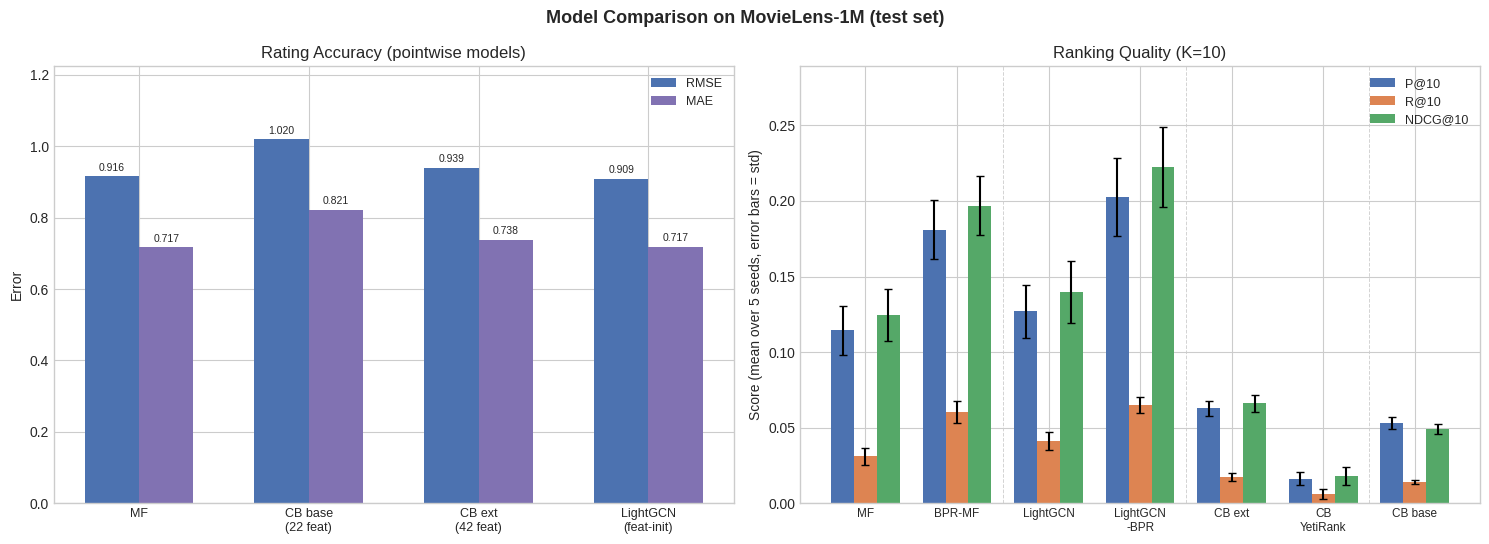

In [ ]:
import matplotlib.ticker as mticker

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
fig.suptitle('Model Comparison on MovieLens-1M (test set)', fontsize=13, fontweight='bold')

# Left panel: RMSE and MAE on the four pointwise rating-prediction models.
rating_models = ['Matrix Factorisation', 'CatBoost (base, 22 feat)',
                 'CatBoost (extended, 42 feat)', 'LightGCN (feat-init)']
rating_short = ['MF', 'CB base\n(22 feat)', 'CB ext\n(42 feat)', 'LightGCN\n(feat-init)']
rmse_vals = df_accuracy.loc[rating_models, 'RMSE'].values.astype(float)
mae_vals = df_accuracy.loc[rating_models, 'MAE'].values.astype(float)
xr = np.arange(len(rating_short))
bw = 0.32
ax = axes[0]
b1 = ax.bar(xr - bw/2, rmse_vals, bw, label='RMSE', color='#4C72B0')
b2 = ax.bar(xr + bw/2, mae_vals, bw, label='MAE', color='#8172B2')
ax.set_xticks(xr); ax.set_xticklabels(rating_short, fontsize=9)
ax.set_ylabel('Error'); ax.set_title('Rating Accuracy (pointwise models)')
ax.set_ylim(0, max(rmse_vals.max(), mae_vals.max()) * 1.20)
ax.yaxis.set_minor_locator(mticker.MultipleLocator(0.05))
ax.legend(fontsize=9)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5)

# Right panel: ranking metrics for the seven variants, grouped pointwise/pairwise.
rank_order = ['MF', 'BPR-MF',
              'LightGCN', 'LightGCN-BPR',
              'CB-ext', 'CB-YetiRank',
              'CB-base']
rank_short = ['MF', 'BPR-MF',
              'LightGCN', 'LightGCN\n-BPR',
              'CB ext', 'CB\nYetiRank',
              'CB base']
means = df_means.loc[rank_order]
p_means = means['P@10'].values.astype(float)
r_means = means['R@10'].values.astype(float)
n_means = means['NDCG@10'].values.astype(float)
std_map = {
    'MF': (mf_p10_std, mf_r10_std, mf_ndcg10_std),
    'BPR-MF': (bpr_p10_std, bpr_r10_std, bpr_ndcg10_std),
    'LightGCN': (lgcn_p10_std, lgcn_r10_std, lgcn_ndcg10_std),
    'LightGCN-BPR': (lgcnbpr_p10_std, lgcnbpr_r10_std, lgcnbpr_ndcg10_std),
    'CB-ext': (cb_p10_std, cb_r10_std, cb_ndcg10_std),
    'CB-YetiRank': (cby_p10_std, cby_r10_std, cby_ndcg10_std),
    'CB-base': (cb_base_p10_std, cb_base_r10_std, cb_base_ndcg10_std),
}
p_stds = [std_map[m][0] for m in rank_order]
r_stds = [std_map[m][1] for m in rank_order]
n_stds = [std_map[m][2] for m in rank_order]

x = np.arange(len(rank_short))
w = 0.25
ax = axes[1]
ax.bar(x - w, p_means, w, yerr=p_stds, label='P@10', color='#4C72B0', capsize=3)
ax.bar(x, r_means, w, yerr=r_stds, label='R@10', color='#DD8452', capsize=3)
ax.bar(x + w, n_means, w, yerr=n_stds, label='NDCG@10', color='#55A868', capsize=3)
ax.set_xticks(x); ax.set_xticklabels(rank_short, fontsize=8.5)
ax.set_ylabel('Score (mean over 5 seeds, error bars = std)')
ax.set_title('Ranking Quality (K=10)')
ax.set_ylim(0, max(p_means.max(), r_means.max(), n_means.max()) * 1.30)
ax.legend(fontsize=9, loc='upper right')
for sep in [1.5, 3.5, 5.5]:
    ax.axvline(sep, color='lightgrey', linewidth=0.7, linestyle='--', zorder=0)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Part 8: Interpretability Analysis

The summary metrics above tell us *which* model performs best on each axis, but not *why*. Interpretability diagnostics close that gap by exposing what each model has actually learned from the mixed-type input. Two model-appropriate diagnostics are reported here:

- **CatBoost feature importances:** for tree-based ensembles, importance scores measure how much each feature contributes to loss reduction across all splits in the boosted ensemble. This identifies which mixed-type features the model relies on, and lets us check whether the engineered statistics added in Part 5b actually pull weight relative to the raw side information.
- **LightGCN learned-embedding analysis:** for graph models, the learned item embeddings encode the structure the GNN has discovered through neighbourhood aggregation. Projecting them to two dimensions and colouring by primary genre lets us check whether items with similar attributes cluster together, which is a direct visual test of whether the graph has captured semantic structure.

### CatBoost feature importance (extended model, 42 features)


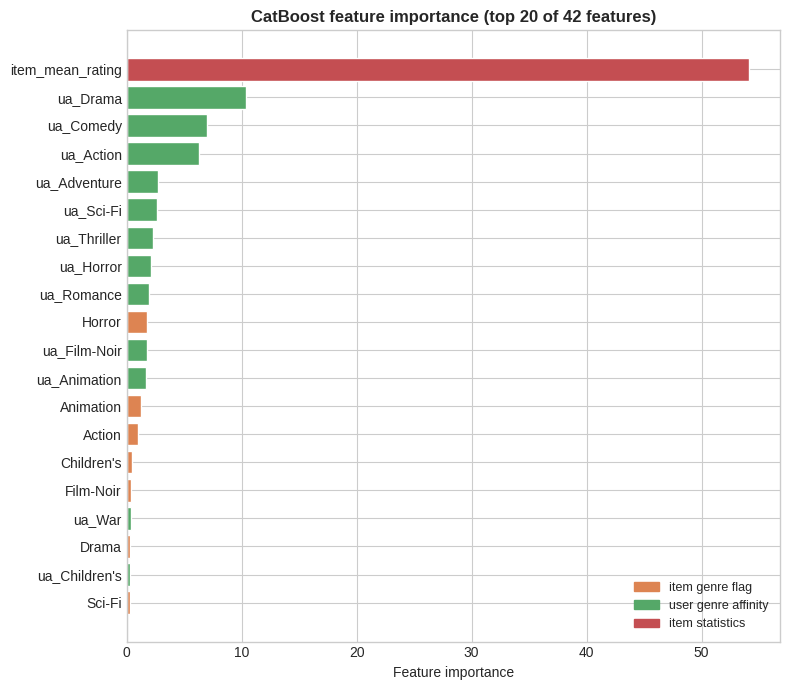


Aggregate importance by feature group:
                        sum    mean  count
group                                     
item statistics      54.104  27.052      2
user genre affinity  39.743   2.208     18
item genre flag       6.003   0.333     18
user demographic      0.150   0.050      3
item year             0.000   0.000      1


In [45]:
importances = cb_model.get_feature_importance()
fi_df = (
    pd.DataFrame({'feature': FEATURE_COLS, 'importance': importances})
      .sort_values('importance', ascending=False)
      .reset_index(drop=True)
)

# Group features by source for colour coding
def feature_group(name):
    if name in {'gender', 'age_scaled', 'occupation'}:
        return 'user demographic'
    if name.startswith('ua_'):
        return 'user genre affinity'
    if name == 'year_scaled':
        return 'item year'
    if name in ALL_GENRES:
        return 'item genre flag'
    if name in {'item_mean_rating', 'item_rating_count'}:
        return 'item statistics'
    return 'other'

fi_df['group'] = fi_df['feature'].map(feature_group)

group_colours = {
    'user demographic':    '#4C72B0',
    'user genre affinity': '#55A868',
    'item year':           '#8172B2',
    'item genre flag':     '#DD8452',
    'item statistics':     '#C44E52',
}

# Top 20 features
top_n = 20
fi_top = fi_df.head(top_n)[::-1]

fig, ax = plt.subplots(figsize=(8, 7))
bar_colours = [group_colours[g] for g in fi_top['group']]
ax.barh(fi_top['feature'], fi_top['importance'], color=bar_colours, edgecolor='white')
ax.set_xlabel('Feature importance')
ax.set_title(f'CatBoost feature importance (top {top_n} of {len(FEATURE_COLS)} features)',
             fontweight='bold')

# Build a legend from group colours actually present in the top-N
present_groups = fi_top['group'].unique().tolist()
handles = [plt.Rectangle((0, 0), 1, 1, color=group_colours[g]) for g in present_groups]
ax.legend(handles, present_groups, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('catboost_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Aggregate importance by feature group
group_summary = (
    fi_df.groupby('group')['importance']
    .agg(['sum', 'mean', 'count'])
    .sort_values('sum', ascending=False)
    .round(3)
)
print('\nAggregate importance by feature group:')
print(group_summary.to_string())

### LightGCN learned item-embedding analysis

Let's project the 64-dimensional item embeddings to 2D via PCA and colour by
primary genre. If genre structure has been captured by message passing,
items of the same genre should occupy similar regions in the 2D plane.


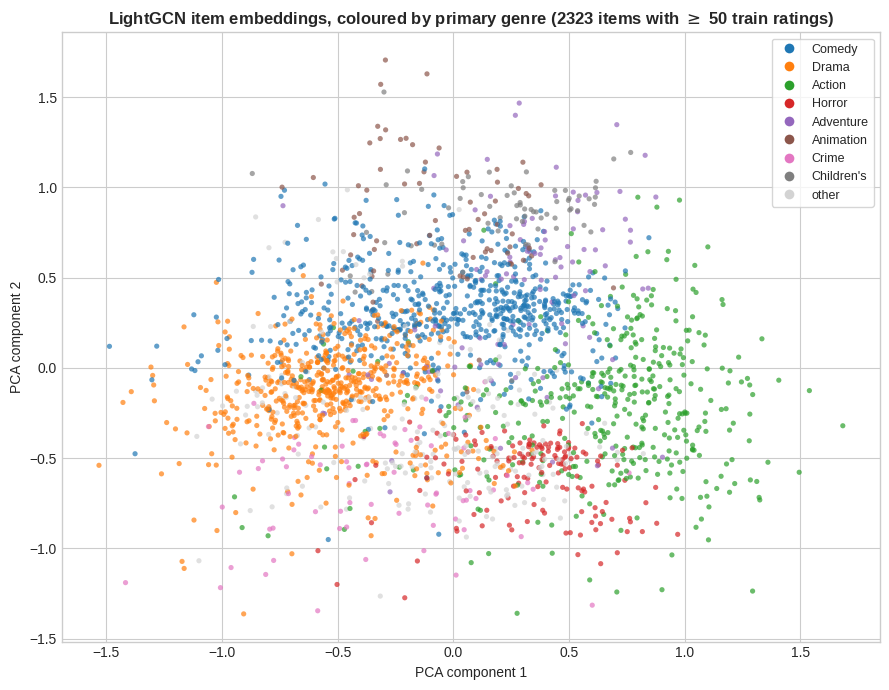

Mean cosine similarity (same primary genre):   0.4432  (n=91,817)
Mean cosine similarity (different genres):     0.0127  (n=407,683)
Difference:                                    +0.4305


In [46]:
from sklearn.decomposition import PCA

# Restrict to items that received a reasonable number of training ratings,
# to avoid noisy embeddings dominating the picture
min_ratings = 50
popular_mids = (
    train_raw.groupby('movie_id').size()
    .loc[lambda s: s >= min_ratings]
    .index.tolist()
)
popular_idx = [movie_to_idx[m] for m in popular_mids]

emb_2d = PCA(n_components=2, random_state=42).fit_transform(_lgcn_i[popular_idx])

# Pick a primary genre per movie: first matching column in ALL_GENRES
def primary_genre(mid):
    row = movies_feat.loc[movies_feat['movie_id'] == mid, ALL_GENRES].iloc[0]
    matches = [g for g in ALL_GENRES if row[g] == 1]
    return matches[0] if matches else 'Other'

primary = [primary_genre(m) for m in popular_mids]

# Restrict colours to the eight most common primary genres for legibility
top_genres = pd.Series(primary).value_counts().head(8).index.tolist()
plot_colour = ['lightgrey'] * len(primary)
palette = sns.color_palette('tab10', n_colors=len(top_genres))
colour_map = {g: palette[i] for i, g in enumerate(top_genres)}
for i, g in enumerate(primary):
    if g in colour_map:
        plot_colour[i] = colour_map[g]

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(emb_2d[:, 0], emb_2d[:, 1], c=plot_colour, s=14, alpha=0.7, edgecolors='none')
ax.set_xlabel('PCA component 1')
ax.set_ylabel('PCA component 2')
ax.set_title(f'LightGCN item embeddings, coloured by primary genre '
             f'({len(popular_mids)} items with $\\geq$ {min_ratings} train ratings)',
             fontweight='bold')

handles = [plt.Line2D([0], [0], marker='o', linestyle='', markersize=7,
                      markerfacecolor=colour_map[g], markeredgecolor='none', label=g)
           for g in top_genres]
handles.append(plt.Line2D([0], [0], marker='o', linestyle='', markersize=7,
                          markerfacecolor='lightgrey', markeredgecolor='none', label='other'))
ax.legend(handles=handles, loc='best', fontsize=9, frameon=True)

plt.tight_layout()
plt.savefig('lightgcn_item_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()

# Quantitative companion: average pairwise cosine similarity within vs across genres
from sklearn.metrics.pairwise import cosine_similarity

sample_n = 1000
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(popular_mids), size=min(sample_n, len(popular_mids)), replace=False)
sample_emb = _lgcn_i[[popular_idx[i] for i in sample_idx]]
sample_genre = np.array([primary[i] for i in sample_idx])

sim = cosine_similarity(sample_emb)
within, across = [], []
for i in range(len(sample_idx)):
    for j in range(i + 1, len(sample_idx)):
        if sample_genre[i] == sample_genre[j]:
            within.append(sim[i, j])
        else:
            across.append(sim[i, j])

print(f'Mean cosine similarity (same primary genre):   {np.mean(within):.4f}  (n={len(within):,})')
print(f'Mean cosine similarity (different genres):     {np.mean(across):.4f}  (n={len(across):,})')
print(f'Difference:                                    {np.mean(within) - np.mean(across):+.4f}')